# Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques et Pandas pour importer,
nettoyer et analyser le dataset, l'étape suivante consiste à représenter graphiquement les
informations afin d'identifier des tendances, des différences entre bâtiments et des anomalies.

In [20]:
# importation des biblio
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
# importation des donnes 
df = pd.read_csv("/home/adama/atelier_matplotlib_iot/data/mesures_capteurs.csv", parse_dates=["date_heure"])
df = df.sort_values("date_heure").reset_index(drop=True)
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0001,2026-01-05 00:00:00,C001,B001,24.91,54.60,1019.00,222.33,OK
1,M0002,2026-01-05 01:00:00,C002,B001,18.15,51.98,1014.02,165.77,OK
2,M0003,2026-01-05 02:00:00,C003,B001,23.95,56.47,1020.04,215.00,OK
3,M0004,2026-01-05 03:00:00,C004,B002,26.20,76.27,1016.74,191.33,OK
4,M0005,2026-01-05 04:00:00,C005,B002,27.11,55.41,1020.03,227.75,OK


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    str           
 1   date_heure    605 non-null    datetime64[us]
 2   id_capteur    605 non-null    str           
 3   batiment      605 non-null    str           
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    str           
dtypes: datetime64[us](1), float64(4), str(4)
memory usage: 42.7 KB


# Partie 1 – Graphique linéaire (Line Plot)

## 1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.

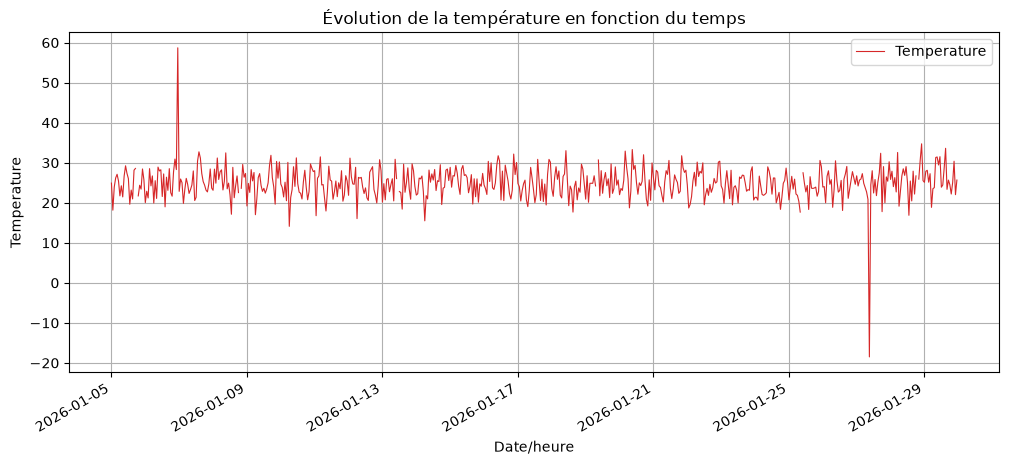

In [27]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["date_heure"], df["temperature"], color = "tab:red", linewidth=0.8)
ax.set_title("Évolution de la température en fonction du temps")
ax.set_xlabel("Date/heure")
ax.set_ylabel("Temperature")
ax.legend(["Temperature"])
ax.grid(True)
fig.autofmt_xdate()
plt.show()

## 2) Identifier visuellement les valeurs qui semblent anormales.

Le graphique permet de repérer des pics ou creux isolés très éloignés du niveau général des autres mesures (valeurs anormalement hautes ou basses, en dehors de la plage habituelle ~19-30°C).

# Partie 2 – Diagramme en barres (Bar Chart)

## 1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments

In [31]:
consommation_batiment = df.groupby("batiment")["consommation"].mean().sort_index()

consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

## 2) Comparer graphiquement la consommation moyenne des bâtiments

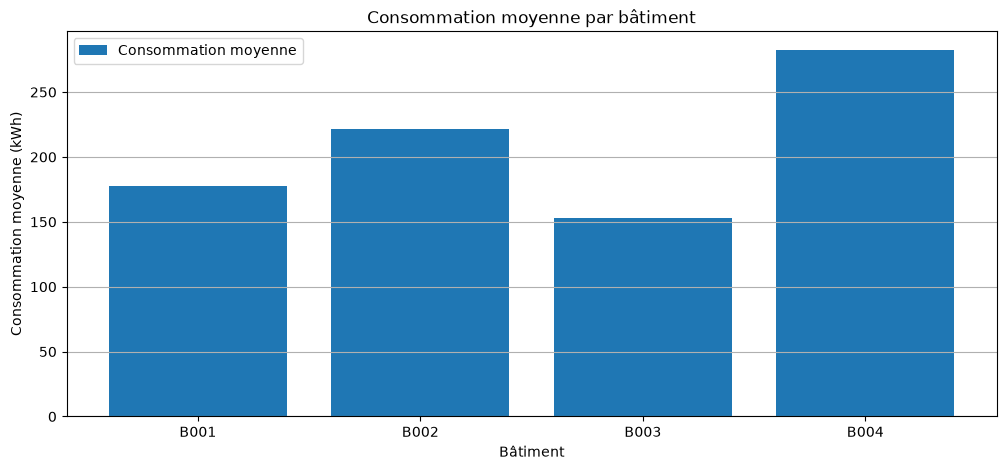

In [33]:
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(consommation_batiment.index, consommation_batiment.values, color="tab:blue")
ax.set_title("Consommation moyenne par bâtiment")
ax.set_xlabel("Bâtiment")
ax.set_ylabel("Consommation moyenne (kWh)")
ax.legend(["Consommation moyenne"])
ax.grid(axis="y")
plt.show()

## 3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal

## 4) Dans quels cas un graphique horizontal peut-il être plus lisible ?

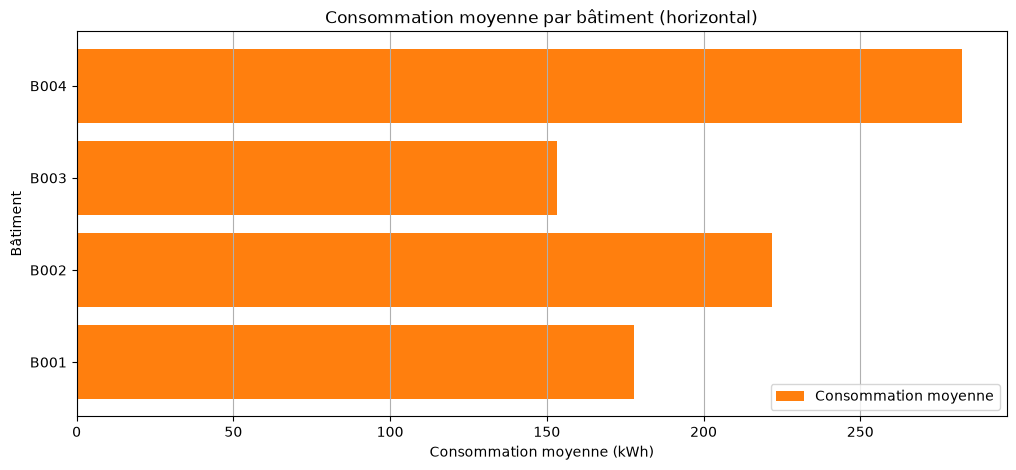

In [34]:
fig, ax = plt.subplots(figsize=(12,5))
ax.barh(consommation_batiment.index, consommation_batiment.values, color="tab:orange")
ax.set_title("Consommation moyenne par bâtiment (horizontal)")
ax.set_xlabel("Consommation moyenne (kWh)")
ax.set_ylabel("Bâtiment")
ax.legend(["Consommation moyenne"])
ax.grid(axis="x")
plt.show()

# Partie 3 – Histogramme

## 1) Afficher la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille

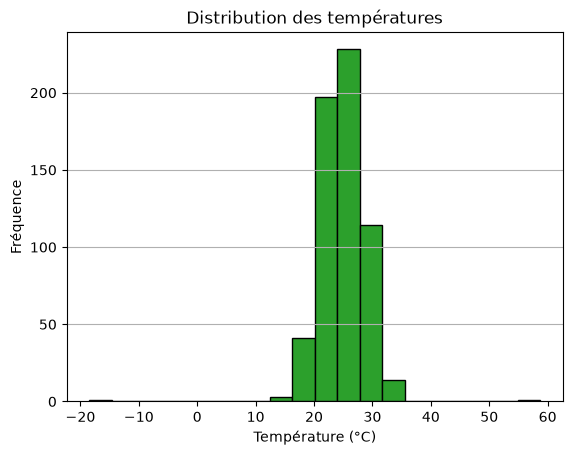

In [42]:
fig, ax = plt.subplots()
ax.hist(df["temperature"].dropna(), bins=20, color="tab:green", edgecolor="black")
ax.set_title("Distribution des températures")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

## 2) Analyser le graphique pour voir

### a) où se concentrent les températures ;

Les températures se concentrent autour de la valeur moyenne (zone centrale de l'histogramme, la plus fournie en effectifs).

### b) si la distribution semble symétrique ;

La distribution semble globalement symétrique, proche d'une forme en cloche, sans asymétrie marquée.

### c) s'il existe des valeurs très éloignées ;

Quelques valeurs isolées apparaissent loin du centre (queues de distribution peu peuplées).

### d) si des valeurs aberrantes sont visibles.

Ces valeurs isolées aux extrémités constituent des valeurs potentiellement aberrantes.

## 3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes

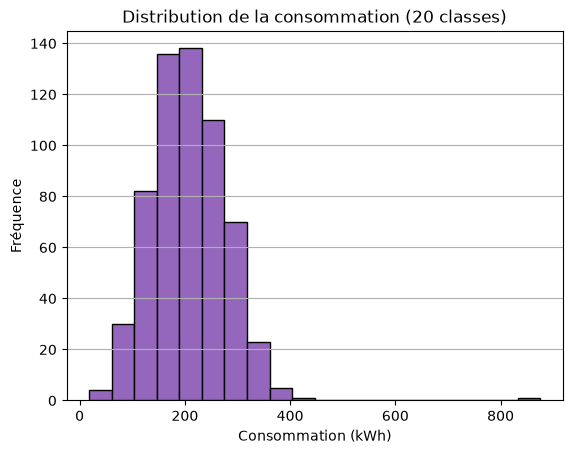

In [39]:
fig, ax = plt.subplots()
ax.hist(df["consommation"].dropna(), bins=20, color="tab:purple", edgecolor="black")
ax.set_title("Distribution de la consommation (20 classes)")
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

### a) Modifier le nombre de classes à 10

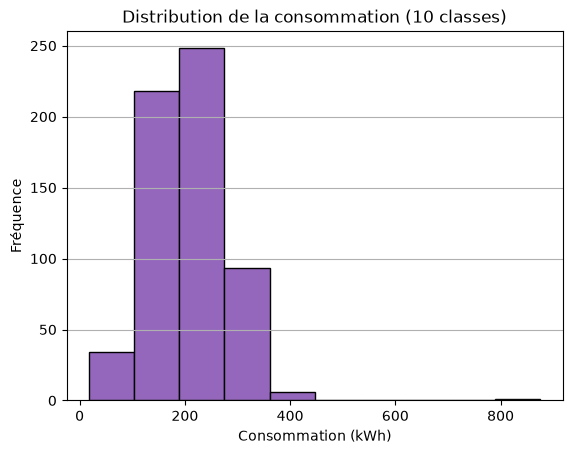

In [40]:
fig, ax = plt.subplots()
ax.hist(df["consommation"].dropna(), bins=10, color="tab:purple", edgecolor="black")
ax.set_title("Distribution de la consommation (10 classes)")
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

### b) Modifier le nombre de classes à 30

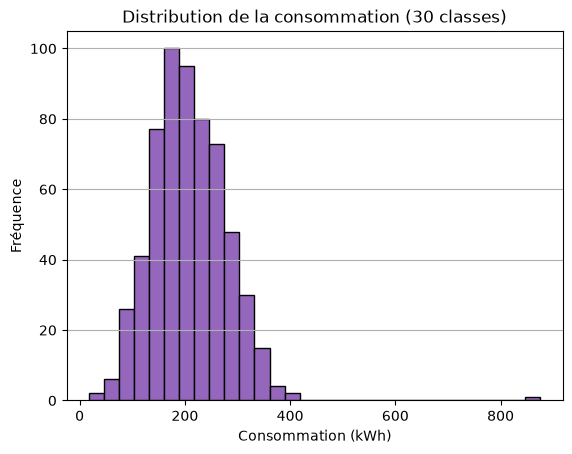

In [41]:
fig, ax = plt.subplots()
ax.hist(df["consommation"].dropna(), bins=30, color="tab:purple", edgecolor="black")
ax.set_title("Distribution de la consommation (30 classes)")
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

### c) Quel impact le nombre de classes a-t-il sur l'interprétation ?

- Peu de classes (10) : la distribution paraît plus lisse, on perd le détail des variations fines mais on voit mieux la tendance globale.
- Beaucoup de classes (30) : on distingue davantage de détails et de variations locales, mais le graphique devient plus bruité et plus difficile à interpréter globalement.
- Un bon compromis (ici 20) permet de voir à la fois la forme générale et les irrégularités significatives.